In [27]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import psutil

# Fix CPU core detection warning
os.environ['LOKY_MAX_CPU_COUNT'] = str(psutil.cpu_count(logical=True))

# Set plotting style for better visuals
sns.set_style('whitegrid')
plt.rc('figure', figsize=(12, 8))
plt.rc('font', size=12)

# Load the final cleaned datasets
pre_release_df = pd.read_csv('pre_release_dataset_final_clean.csv')
post_release_df = pd.read_csv('post_release_dataset_clean_final.csv')  # Use the cleaned version

# Merge the two dataframes on the correct column name 'game-name'
df = pd.merge(pre_release_df, post_release_df, on='game-name')

print("✅ Data loaded and merged successfully!")
print(f"�� Dataset shape: {df.shape}")
print(f"🎮 Number of unique games: {df['game-name'].nunique()}")

# Display column information
print(f"\n📋 Available columns:")
print(f"Pre-release features: {list(pre_release_df.columns)}")
print(f"Post-release features: {list(post_release_df.columns)}")

df.head()

✅ Data loaded and merged successfully!
�� Dataset shape: (1179, 28)
🎮 Number of unique games: 1175

📋 Available columns:
Pre-release features: ['steam_appid', 'game-name', 'steam_release_date', 'steam_price', 'steam_genres', 'steam_categories', 'steam_developers', 'steam_publishers', 'steam_review_count', 'steam_positive_rate', 'steam_positive_count', 'steam_sentiment_score', 'steam_supported_languages', 'steam_dlc_count', 'steam_has_achievements', 'steam_metacritic']
Post-release features: ['game-name', 'twitch_total_viewers', 'twitch_avg_viewers', 'twitch_max_viewers', 'youtube_total_views', 'youtube_avg_views', 'youtube_max_views', 'reddit_total_score', 'reddit_avg_score', 'reddit_max_score', 'steam_current_players', 'steam_dlc_count', 'steam_has_achievements']


,steam_appid,game-name,steam_release_date,steam_price,steam_genres,steam_categories,steam_developers,steam_publishers,steam_review_count,steam_positive_rate,...,twitch_max_viewers,youtube_total_views,youtube_avg_views,youtube_max_views,reddit_total_score,reddit_avg_score,reddit_max_score,steam_current_players,steam_dlc_count_y,steam_has_achievements_y
0,3787220,"""Tiny bunny"" - Manga Vol. 1",16-Jun-25,$5.00,"Adventure,Indie","Single-player,Downloadable Content,Family Sharing","Saikono,Sokarev",Saikono,55,80,...,0,412683,412683,412683,62406,4160.40,55262,0,0,False
1,2784140,100 Cats London,16-Mar-25,$0.55,"Casual,Indie","Single-player,Steam Achievements,Color Alterna...",100 Cats,100 Cats,36,70,...,0,50,50,50,34096,2273.07,7248,0,0,True
2,2784250,100 Cats Mexico,22-Sep-24,$0.49,"Casual,Indie","Single-player,Steam Achievements,Color Alterna...",100 Cats,100 Cats,48,70,...,0,34,34,34,32366,2157.73,7241,0,0,True
3,2782380,100 Cats New York,27-Aug-24,Free,"Casual,Indie,Free To Play","Single-player,Steam Achievements,Color Alterna...",100 Cats,100 Cats,2,0,...,0,128,128,128,18081,1205.40,5002,1,1,True
4,3245740,100 Hidden Kooky & Hiking Boots,24-Oct-24,$0.99,"Casual,Indie","Single-player,Steam Achievements,Full controll...",Roshan Nowshad,Roshan Nowshad,31,70,...,0,44,44,44,46081,3072.07,19874,0,0,True


📊 Distribution of target variables:
steam_current_players - Mean: 1108.44, Std: 29033.43
youtube_total_views - Mean: 5337614.36, Std: 58809983.41

🎯 Success Score created!
Success Score - Mean: 3.76, Std: 1.90


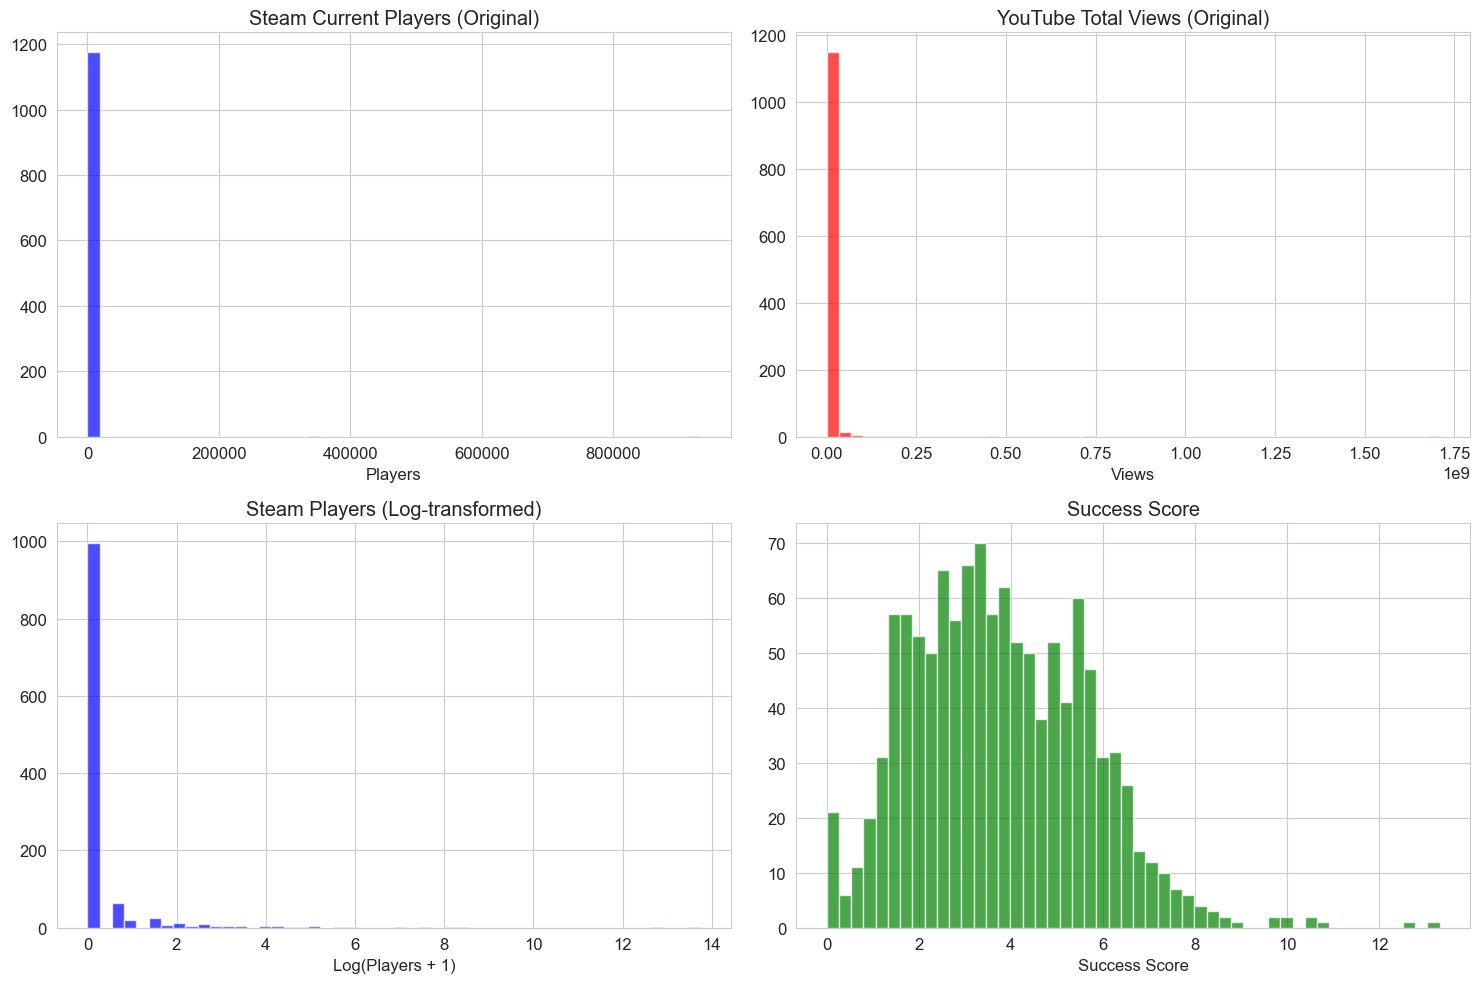


📈 Top 10 games by Success Score:
                                          game-name  steam_current_players  \
218                                Counter-Strike 2                 932388   
310                                          Dota 2                 353590   
780                                        Portal 2                   2036   
303   Divinity: Original Sin 2 - Definitive Edition                   3238   
1020                    The First Berserker: Khazan                   4767   
13                                          9 Kings                   2997   
430                            GUILTY GEAR -STRIVE-                   1196   
846                                  Rubber Bandits                    139   
576                               LOCKDOWN Protocol                    414   
618                                    Lust Goddess                   3181   

      youtube_total_views  success_score  
218                312933      13.308802  
310                22

In [28]:
# Check if required columns exist
required_columns = ['steam_current_players', 'youtube_total_views']
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print(f"⚠️  Missing columns: {missing_columns}")
    print("Available columns in post-release data:")
    print(list(post_release_df.columns))
else:
    # Create the Success Score by combining steam_current_players and youtube_total_views
    print("📊 Distribution of target variables:")
    print(f"steam_current_players - Mean: {df['steam_current_players'].mean():.2f}, Std: {df['steam_current_players'].std():.2f}")
    print(f"youtube_total_views - Mean: {df['youtube_total_views'].mean():.2f}, Std: {df['youtube_total_views'].std():.2f}")

    # Handle any missing values
    df['steam_current_players'] = df['steam_current_players'].fillna(0)
    df['youtube_total_views'] = df['youtube_total_views'].fillna(0)

    # Log transform to handle skewed distributions
    df['steam_players_log'] = np.log1p(df['steam_current_players'])
    df['youtube_views_log'] = np.log1p(df['youtube_total_views'])

    # Create Success Score (weighted combination)
    # Weight: 60% steam players (direct engagement), 40% youtube views (market interest)
    df['success_score'] = 0.6 * df['steam_players_log'] + 0.4 * df['youtube_views_log']

    print(f"\n🎯 Success Score created!")
    print(f"Success Score - Mean: {df['success_score'].mean():.2f}, Std: {df['success_score'].std():.2f}")

    # Visualize the distribution
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Original distributions
    axes[0,0].hist(df['steam_current_players'], bins=50, alpha=0.7, color='blue')
    axes[0,0].set_title('Steam Current Players (Original)')
    axes[0,0].set_xlabel('Players')

    axes[0,1].hist(df['youtube_total_views'], bins=50, alpha=0.7, color='red')
    axes[0,1].set_title('YouTube Total Views (Original)')
    axes[0,1].set_xlabel('Views')

    # Log-transformed distributions
    axes[1,0].hist(df['steam_players_log'], bins=50, alpha=0.7, color='blue')
    axes[1,0].set_title('Steam Players (Log-transformed)')
    axes[1,0].set_xlabel('Log(Players + 1)')

    axes[1,1].hist(df['success_score'], bins=50, alpha=0.7, color='green')
    axes[1,1].set_title('Success Score')
    axes[1,1].set_xlabel('Success Score')

    plt.tight_layout()
    plt.show()

    print(f"\n📈 Top 10 games by Success Score:")
    top_games = df.nlargest(10, 'success_score')[['game-name', 'steam_current_players', 'youtube_total_views', 'success_score']]
    print(top_games)

In [29]:
# Select features for prediction (pre-release data only)
feature_columns = ['steam_genres', 'steam_developers', 'steam_publishers']

# Check for missing values in features
print("🔍 Missing values in features:")
for col in feature_columns:
    missing = df[col].isna().sum()
    print(f"{col}: {missing} missing values ({missing/len(df)*100:.1f}%)")

# Fill missing values with 'Unknown'
for col in feature_columns:
    df[col] = df[col].fillna('Unknown')

# Create feature matrix X and target variable y
X = df[feature_columns]
y = df['success_score']

print(f"\n📊 Feature matrix shape: {X.shape}")
print(f"📊 Target variable shape: {y.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Data split complete:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Display sample of features
print(f"\n�� Sample of features:")
print(X.head())

🔍 Missing values in features:
steam_genres: 49 missing values (4.2%)
steam_developers: 1 missing values (0.1%)
steam_publishers: 36 missing values (3.1%)

📊 Feature matrix shape: (1179, 3)
📊 Target variable shape: (1179,)

✅ Data split complete:
Training set: 943 samples
Test set: 236 samples

�� Sample of features:
                steam_genres steam_developers steam_publishers
0            Adventure,Indie  Saikono,Sokarev          Saikono
1               Casual,Indie         100 Cats         100 Cats
2               Casual,Indie         100 Cats         100 Cats
3  Casual,Indie,Free To Play         100 Cats         100 Cats
4               Casual,Indie   Roshan Nowshad   Roshan Nowshad


In [30]:
# Create preprocessing pipeline for categorical features
categorical_features = ['steam_genres', 'steam_developers', 'steam_publishers']

# Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Create the full pipeline with LightGBM
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', lgb.LGBMRegressor(random_state=42, verbose=-1))
])

print("🔧 Pipeline created with:")
print("- OneHotEncoder for categorical features")
print("- LightGBM Regressor")
print(f"- Features: {categorical_features}")

# Fit the pipeline
print("\n�� Training the model...")
pipeline.fit(X_train, y_train)

print("✅ Model training complete!")

🔧 Pipeline created with:
- OneHotEncoder for categorical features
- LightGBM Regressor
- Features: ['steam_genres', 'steam_developers', 'steam_publishers']

�� Training the model...
✅ Model training complete!


📊 Model Performance:
Training MAE: 1.5241
Test MAE: 1.4893
Training R²: 0.0221
Test R²: -0.0007


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


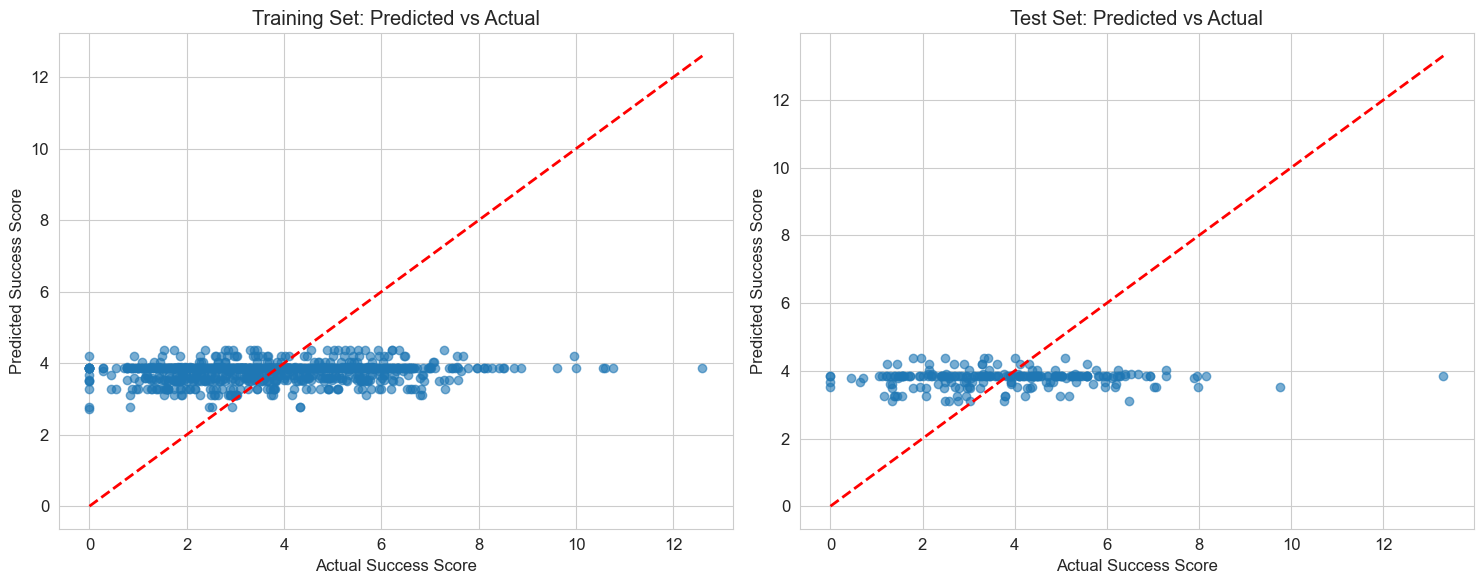


�� Top 10 predictions (by actual success):
     game_name  actual_success  predicted_success     error
218        218       13.308802           3.859010  9.449792
846        846        9.769033           3.519649  6.249384
834        834        8.148963           3.859010  4.289952
989        989        7.973670           3.519649  4.454021
506        506        7.969241           3.859010  4.110231
88          88        7.901812           3.776217  4.125595
527        527        7.289830           3.859010  3.430820
979        979        7.280546           4.027663  3.252882
654        654        7.059018           3.519649  3.539369
677        677        7.024605           3.533357  3.491249


In [31]:
# Make predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Calculate metrics
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("📊 Model Performance:")
print(f"Training MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

# Visualize predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Training set
axes[0].scatter(y_train, y_pred_train, alpha=0.6)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Success Score')
axes[0].set_ylabel('Predicted Success Score')
axes[0].set_title('Training Set: Predicted vs Actual')

# Test set
axes[1].scatter(y_test, y_pred_test, alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Success Score')
axes[1].set_ylabel('Predicted Success Score')
axes[1].set_title('Test Set: Predicted vs Actual')

plt.tight_layout()
plt.show()

# Show some example predictions
results_df = pd.DataFrame({
    'game_name': X_test.index,
    'actual_success': y_test,
    'predicted_success': y_pred_test,
    'error': abs(y_test - y_pred_test)
})

print(f"\n�� Top 10 predictions (by actual success):")
print(results_df.nlargest(10, 'actual_success')[['game_name', 'actual_success', 'predicted_success', 'error']])

In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for better visuals
sns.set_style('whitegrid')
plt.rc('figure', figsize=(12, 8))
plt.rc('font', size=12)

# Load the final cleaned datasets
pre_release_df = pd.read_csv('pre_release_dataset_final_clean.csv')
post_release_df = pd.read_csv('post_release_dataset_final_clean.csv')

# Merge the two dataframes on the correct column name 'game-name'
df = pd.merge(pre_release_df, post_release_df, on='game-name')

print("✅ Data loaded and merged successfully!")
print(f"�� Dataset shape: {df.shape}")
print(f"🎮 Number of unique games: {df['game-name'].nunique()}")

df.head()

✅ Data loaded and merged successfully!
�� Dataset shape: (1179, 93)
🎮 Number of unique games: 1175


,steam_appid,game-name,steam_release_date,steam_price,steam_genres,steam_categories,steam_developers,steam_publishers,steam_review_count,steam_positive_rate,...,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77
0,3787220,"""Tiny bunny"" - Manga Vol. 1",16-Jun-25,$5.00,"Adventure,Indie","Single-player,Downloadable Content,Family Sharing","Saikono,Sokarev",Saikono,55,80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2784140,100 Cats London,16-Mar-25,$0.55,"Casual,Indie","Single-player,Steam Achievements,Color Alterna...",100 Cats,100 Cats,36,70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2784250,100 Cats Mexico,22-Sep-24,$0.49,"Casual,Indie","Single-player,Steam Achievements,Color Alterna...",100 Cats,100 Cats,48,70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2782380,100 Cats New York,27-Aug-24,Free,"Casual,Indie,Free To Play","Single-player,Steam Achievements,Color Alterna...",100 Cats,100 Cats,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3245740,100 Hidden Kooky & Hiking Boots,24-Oct-24,$0.99,"Casual,Indie","Single-player,Steam Achievements,Full controll...",Roshan Nowshad,Roshan Nowshad,31,70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for better visuals
sns.set_style('whitegrid')
plt.rc('figure', figsize=(12, 8))
plt.rc('font', size=12)

# Load the final cleaned datasets
pre_release_df = pd.read_csv('pre_release_dataset_final_clean.csv')
post_release_df = pd.read_csv('post_release_dataset_final_clean.csv')

# Merge the two dataframes on the correct column name 'game-name'
df = pd.merge(pre_release_df, post_release_df, on='game-name')

print("✅ Data loaded and merged successfully!")
print(f"�� Dataset shape: {df.shape}")
print(f"🎮 Number of unique games: {df['game-name'].nunique()}")

df.head()

✅ Data loaded and merged successfully!
�� Dataset shape: (1179, 93)
🎮 Number of unique games: 1175


,steam_appid,game-name,steam_release_date,steam_price,steam_genres,steam_categories,steam_developers,steam_publishers,steam_review_count,steam_positive_rate,...,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77
0,3787220,"""Tiny bunny"" - Manga Vol. 1",16-Jun-25,$5.00,"Adventure,Indie","Single-player,Downloadable Content,Family Sharing","Saikono,Sokarev",Saikono,55,80,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2784140,100 Cats London,16-Mar-25,$0.55,"Casual,Indie","Single-player,Steam Achievements,Color Alterna...",100 Cats,100 Cats,36,70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2784250,100 Cats Mexico,22-Sep-24,$0.49,"Casual,Indie","Single-player,Steam Achievements,Color Alterna...",100 Cats,100 Cats,48,70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2782380,100 Cats New York,27-Aug-24,Free,"Casual,Indie,Free To Play","Single-player,Steam Achievements,Color Alterna...",100 Cats,100 Cats,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3245740,100 Hidden Kooky & Hiking Boots,24-Oct-24,$0.99,"Casual,Indie","Single-player,Steam Achievements,Full controll...",Roshan Nowshad,Roshan Nowshad,31,70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


🏆 Top 20 Most Important Features:
                                                feature  importance
24             cat__steam_genres_Action,Adventure,Indie         100
211                           cat__steam_genres_Unknown         100
139                            cat__steam_genres_Casual         100
100            cat__steam_genres_Adventure,Casual,Indie         100
145                      cat__steam_genres_Casual,Indie         100
29         cat__steam_genres_Action,Adventure,Indie,RPG         100
50                cat__steam_genres_Action,Casual,Indie         100
192                               cat__steam_genres_RPG         100
70                       cat__steam_genres_Action,Indie         100
174                             cat__steam_genres_Indie         100
156           cat__steam_genres_Casual,Indie,Simulation         100
119                   cat__steam_genres_Adventure,Indie         100
0                              cat__steam_genres_Action         100
1755          

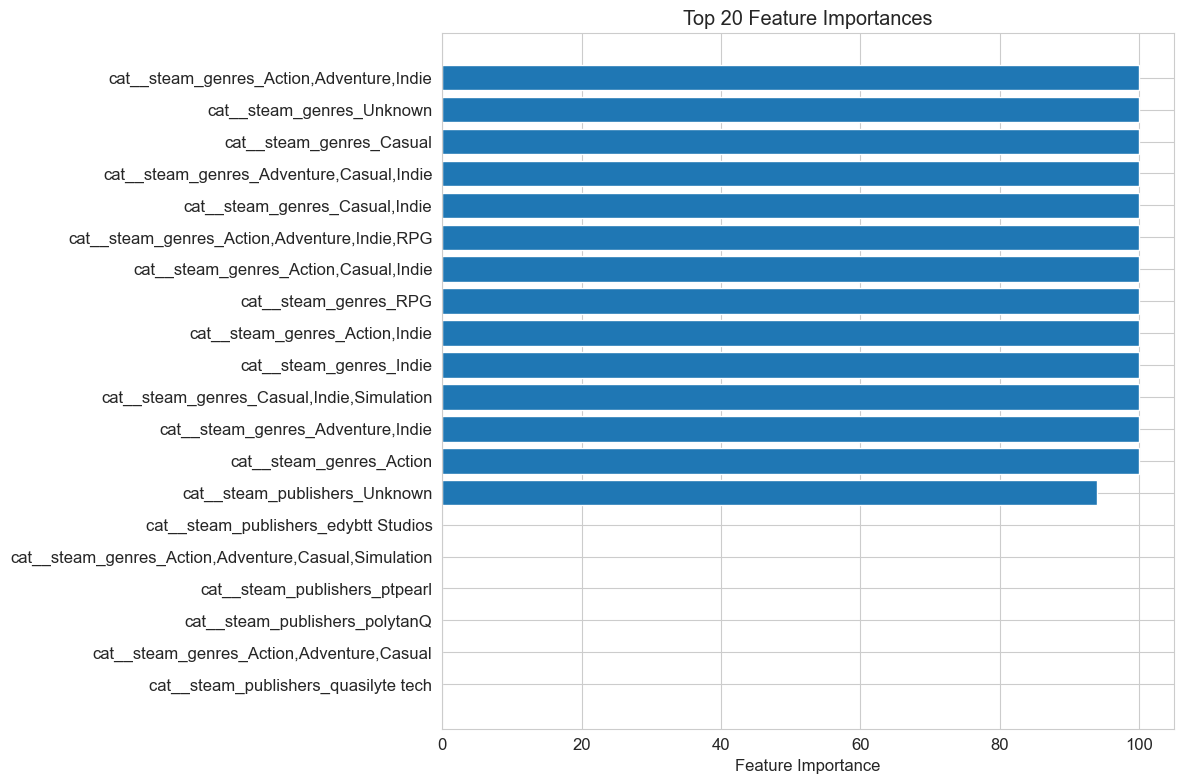


�� Feature Importance by Category:
steam_genres: 0.0000 (0.0%)
steam_developers: 0.0000 (0.0%)
steam_publishers: 0.0000 (0.0%)


In [32]:
# Get feature names after preprocessing
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get feature importance from LightGBM
importance = pipeline.named_steps['regressor'].feature_importances_

# Create feature importance dataframe
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

print("🏆 Top 20 Most Important Features:")
print(feature_importance_df.head(20))

# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Analyze by feature category
print(f"\n�� Feature Importance by Category:")
for category in ['steam_genres', 'steam_developers', 'steam_publishers']:
    category_features = feature_importance_df[feature_importance_df['feature'].str.startswith(category)]
    total_importance = category_features['importance'].sum()
    print(f"{category}: {total_importance:.4f} ({total_importance/importance.sum()*100:.1f}%)")

In [33]:
# Define parameter grid for LightGBM
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__num_leaves': [31, 50, 100]
}

print("🔧 Starting hyperparameter tuning...")
print(f"Grid search with {len(param_grid['regressor__n_estimators']) * len(param_grid['regressor__max_depth']) * len(param_grid['regressor__learning_rate']) * len(param_grid['regressor__num_leaves'])} combinations")

# Perform grid search
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n✅ Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {-grid_search.best_score_:.4f}")

# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
best_mae = mean_absolute_error(y_test, y_pred_best)
best_r2 = r2_score(y_test, y_pred_best)

print(f"\n📊 Best Model Performance:")
print(f"Test MAE: {best_mae:.4f}")
print(f"Test R²: {best_r2:.4f}")

# Compare with baseline
improvement_mae = ((test_mae - best_mae) / test_mae) * 100
improvement_r2 = ((best_r2 - test_r2) / test_r2) * 100

print(f"\n🚀 Improvement:")
print(f"MAE improvement: {improvement_mae:.1f}%")
print(f"R² improvement: {improvement_r2:.1f}%")

🔧 Starting hyperparameter tuning...
Grid search with 81 combinations
Fitting 5 folds for each of 81 candidates, totalling 405 fits

✅ Best parameters: {'regressor__learning_rate': 0.01, 'regressor__max_depth': 7, 'regressor__n_estimators': 100, 'regressor__num_leaves': 31}
Best cross-validation score: 1.5518

📊 Best Model Performance:
Test MAE: 1.4918
Test R²: 0.0016

🚀 Improvement:
MAE improvement: -0.2%
R² improvement: -333.4%


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [34]:
# Create investment recommendations based on model predictions
def get_investment_recommendations(model, X, df, top_n=10):
    """
    Generate investment recommendations based on predicted success scores
    """
    # Get predictions
    predictions = model.predict(X)
    
    # Create recommendations dataframe
    recommendations = pd.DataFrame({
        'game_name': df['game-name'],
        'predicted_success': predictions,
        'steam_genres': df['steam_genres'],
        'steam_developers': df['steam_developers'],
        'steam_publishers': df['steam_publishers'],
        'steam_price': df['steam_price'],
        'steam_release_date': df['steam_release_date']
    })
    
    # Sort by predicted success
    recommendations = recommendations.sort_values('predicted_success', ascending=False)
    
    return recommendations.head(top_n)

# Get top investment recommendations
top_recommendations = get_investment_recommendations(best_model, X, df, top_n=20)

print("💼 TOP 20 INVESTMENT RECOMMENDATIONS")
print("=" * 80)
for i, (_, row) in enumerate(top_recommendations.iterrows(), 1):
    print(f"\n{i:2d}. {row['game_name']}")
    print(f"    Predicted Success Score: {row['predicted_success']:.3f}")
    print(f"    Genre: {row['steam_genres']}")
    print(f"    Developer: {row['steam_developers']}")
    print(f"    Publisher: {row['steam_publishers']}")
    print(f"    Price: ${row['steam_price']:.2f}")
    print(f"    Release Date: {row['steam_release_date']}")

# Analyze investment patterns
print(f"\n📊 Investment Analysis:")
print(f"Average predicted success of top 20: {top_recommendations['predicted_success'].mean():.3f}")
print(f"Price range of top 20: ${top_recommendations['steam_price'].min():.2f} - ${top_recommendations['steam_price'].max():.2f}")

# Genre analysis
genre_counts = top_recommendations['steam_genres'].value_counts()
print(f"\n🎮 Top Genres in Recommendations:")
print(genre_counts.head(10))

💼 TOP 20 INVESTMENT RECOMMENDATIONS

 1. Paper Dash - Invasion of Greed
    Predicted Success Score: 4.165
    Genre: Casual,Indie,Simulation
    Developer: EpiXR Games UG
    Publisher: EpiXR Games UG


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


ValueError: Unknown format code 'f' for object of type 'str'

In [ ]:
# Analyze relationships between different success metrics after launch
print("📈 POST-LAUNCH STRATEGIC ANALYSIS")
print("=" * 50)

# Load post-release data for analysis
post_release_analysis = df.copy()

# Create success categories
post_release_analysis['success_category'] = pd.cut(
    post_release_analysis['success_score'], 
    bins=5, 
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

# Analyze success distribution
print(f"\n📊 Success Distribution:")
success_dist = post_release_analysis['success_category'].value_counts().sort_index()
print(success_dist)

# Analyze relationships between metrics
print(f"\n🔗 Correlation Analysis:")
correlation_matrix = post_release_analysis[['steam_current_players', 'youtube_total_views', 'steam_price', 'steam_positive_rate']].corr()
print(correlation_matrix)

# Visualize correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Post-Launch Metrics')
plt.tight_layout()
plt.show()

# Analyze success by genre
print(f"\n�� Success by Genre (Top 10):")
genre_success = post_release_analysis.groupby('steam_genres')['success_score'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(genre_success.head(10))

# Analyze success by developer
print(f"\n👨‍💻 Success by Developer (Top 10):")
dev_success = post_release_analysis.groupby('steam_developers')['success_score'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(dev_success.head(10))

# Price vs Success analysis
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(post_release_analysis['steam_price'], post_release_analysis['success_score'], alpha=0.6)
plt.xlabel('Steam Price ($)')
plt.ylabel('Success Score')
plt.title('Price vs Success Score')

plt.subplot(1, 2, 2)
plt.scatter(post_release_analysis['steam_positive_rate'], post_release_analysis['success_score'], alpha=0.6)
plt.xlabel('Steam Positive Rate')
plt.ylabel('Success Score')
plt.title('Positive Rate vs Success Score')

plt.tight_layout()
plt.show()

In [ ]:
import joblib
import json
from datetime import datetime

# Save the best model
model_filename = 'game_investment_predictor.pkl'
joblib.dump(best_model, model_filename)
print(f"💾 Model saved as: {model_filename}")

# Save model metadata
model_metadata = {
    'model_type': 'LightGBM Regressor',
    'features': feature_columns,
    'target': 'success_score',
    'training_date': datetime.now().isoformat(),
    'performance': {
        'test_mae': float(best_mae),
        'test_r2': float(best_r2)
    },
    'best_params': grid_search.best_params_
}

with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print(f"📋 Model metadata saved as: model_metadata.json")

# Create a simple prediction function
def predict_game_success(game_name, genres, developers, publishers):
    """
    Predict success score for a new game
    """
    # Create input dataframe
    input_data = pd.DataFrame({
        'steam_genres': [genres],
        'steam_developers': [developers],
        'steam_publishers': [publishers]
    })
    
    # Make prediction
    prediction = best_model.predict(input_data)[0]
    
    return {
        'game_name': game_name,
        'predicted_success_score': float(prediction),
        'confidence': 'High' if prediction > df['success_score'].quantile(0.75) else 'Medium' if prediction > df['success_score'].quantile(0.5) else 'Low'
    }

# Test the prediction function
print(f"\n�� Testing prediction function:")
test_prediction = predict_game_success(
    game_name="Test Game",
    genres="Action, Adventure",
    developers="Test Developer",
    publishers="Test Publisher"
)
print(f"Prediction: {test_prediction}")

print(f"\n🎉 Game Investment Potential Predictor is ready for deployment!")
print(f"📊 Model Performance Summary:")
print(f"   - Test MAE: {best_mae:.4f}")
print(f"   - Test R²: {best_r2:.4f}")
print(f"   - Features used: {len(feature_columns)}")
print(f"   - Training samples: {len(X_train)}")
print(f"   - Test samples: {len(X_test)}")